In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = -0.2
tmax=1.0
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

Not setting metadata
4200 matching events found
No baseline correction applied
Not setting metadata
4200 matching events found
No baseline correction applied


No projector specified for this dataset. Please consider the method self.add_proj.


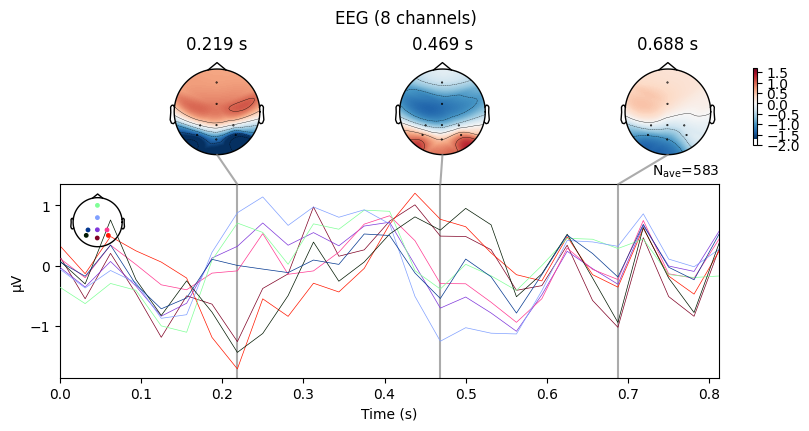

In [6]:
from mne import combine_evoked

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1, -1])
contrast.crop(0,0.8)
contrast.plot_joint();

In [4]:
from mne.time_frequency import tfr_morlet
import numpy as np

freqs = np.linspace(0.5,16,16)
cycles = freqs*0.7
epochs_tfr = tfr_morlet(epochs, freqs, cycles, return_itc=False, average=False)
epochs_tfr.apply_baseline((-0.15,-0.05), mode='logratio')
epochs_tfr.crop(0,0.8)

Not setting metadata
Applying baseline correction (mode: logratio)


<EpochsTFR | time : [0.000000, 0.812500], freq : [0.500000, 16.000000], epochs : 4200, channels : 8, ~110.8 MB>

No baseline correction applied


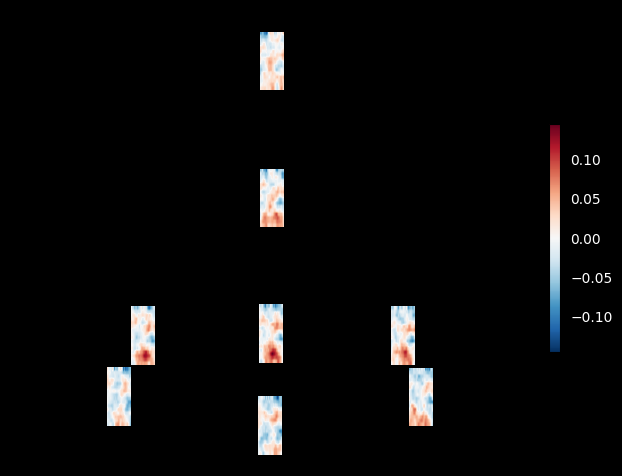

In [7]:
tfr_target = epochs_tfr['Target'].average()
tfr_non_target = epochs_tfr['NonTarget'].average()
tfr_contrast = combine_evoked([tfr_target, tfr_non_target], weights=[1,-1])
tfr_contrast.plot_topo();